# Looking at the DESC equilibria

In [1]:
from desc import set_device
set_device("gpu")
from aqsc import aqsc_to_desc_near_axis
from desc.examples import get, listall
from desc.plotting import *
from scipy.constants import mu_0
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

2026-08-12 14:39:53.524801: W external/xla/xla/stream_executor/cuda/cuda_command_buffer.cc:725] Retry CUDA graph instantiation after OOM error
E0812 14:39:53.524838   57811 pjrt_stream_executor_client.cc:2916] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Underlying backend ran out of memory trying to instantiate command buffer with 5 (total of 0 alive graphs in the process). You can try to (a) Give more memory to the driver by reducing XLA_CLIENT_MEM_FRACTION (b) Disable command buffers with 'XLA_FLAGS=--xla_gpu_enable_command_buffer=' (empty set). Original error: Failed to instantiate CUDA graph: CUDA_ERROR_OUT_OF_MEMORY: out of memory


XlaRuntimeError: RESOURCE_EXHAUSTED: Underlying backend ran out of memory trying to instantiate command buffer with 5 (total of 0 alive graphs in the process). You can try to (a) Give more memory to the driver by reducing XLA_CLIENT_MEM_FRACTION (b) Disable command buffers with 'XLA_FLAGS=--xla_gpu_enable_command_buffer=' (empty set). Original error: Failed to instantiate CUDA graph: CUDA_ERROR_OUT_OF_MEMORY: out of memory

In [ ]:
from shared import * 

In [3]:
eq_init = solve_order_6(x_flat_init, padded=True)

Default interpolation method: cubic
Solving for \bar{\iota}_0 self-consistently.
Evaluating order 3 4
Evaluating order 5 6


In [8]:
i_test = 1
# eq_fin = jnp.load(f'pass_2/best_x.npy', allow_pickle=True).item()
x_fin = jnp.load(f'./best_x.npy')
eq_fin = solve_order_6(x_fin, padded=True)
fin_eps_conv = eps_conv(eq_fin)

In [9]:
%%time
psi_crit, _, _ = eq_fin.get_psi_crit()
A_fin = eq_fin.aspect_ratio_eps(jnp.sqrt(psi_crit))

CPU times: user 1.89 s, sys: 405 ms, total: 2.3 s
Wall time: 1.79 s


In [10]:
w_aspect = 1
w_anisotropy = 1
w_iota = 1
w_p = 1
target_aspect=10
target_anisotropy=.01
target_iota=.1
eq = eq_fin
anisotropy = rms_anisotropy(eq)

psi_crit, _, _ = eq.get_psi_crit()
eps_crit_val = jnp.sqrt(psi_crit)
eps_conv_val = eps_conv(eq)
eps = jnp.minimum(eps_conv_val, eps_crit_val)
aspect = eq.aspect_ratio_eps(eps)

# Iota
iota_a = jnp.real(eq.iota.eval(psi=0, chi=0, phi=0))

# Effective field strength at the edge
# B_denom_20 = jnp.real(in_dict['B20'])|
# Effective pressure at the edge
p20_avg = jnp.real(jnp.average(eq.p_perp[2][0].content))
p00_avg = jnp.real(jnp.average(eq.p_perp[0][0].content))
p_edge_eff = (p00_avg + p20_avg*eps**2)
p_axis_eff = p00_avg
# # beta_edge eff
# beta_axis_eff = p00_avg*B_denom_0
# beta_edge_eff = p_edge_eff*B_denom_edge_eff
# B2_eff = 1/(B_denom_0 + B_denom_20 * eps**2)
term1 = w_aspect * (
    jnp.maximum(aspect - target_aspect, 0) / target_aspect
)**2
term2 = w_anisotropy * (
    jnp.maximum(anisotropy - target_anisotropy, 0) / target_anisotropy
)**2
term3 = w_iota * (
    jnp.maximum(jnp.abs(target_iota) - jnp.abs(iota_a), 0) / target_iota
)**2
# term4 = w_p * (
#     jnp.maximum(p20_avg, 0) / p20_avg
# )**2
term4 = w_p * (
    jnp.maximum(p_edge_eff - p_axis_eff, 0) / p_axis_eff
)**2
out = term1 + term2 + term3 + term4
print('term1', term1)
print('term2', term2)
print('term3', term3)
print('term4', term4)
print('eps_crit', eps_crit_val,)
print('eps_conv', eps_conv_val,)
print('aspect', aspect,)
print('anisotropy', anisotropy,)
print('p_edge_eff', p_edge_eff,)
print('p_axis_eff', p_axis_eff,)
print('iota_a', iota_a,)


term1 1.1450303664976005
term2 0.08794255605775372
term3 0.0
term4 0.0
eps_crit 0.037764357620542977
eps_conv 0.037156058981163066
aspect 20.70060917190045
anisotropy 0.012965511019331301
p_edge_eff 0.009922978313201271
p_axis_eff 0.010301206706096005
iota_a -0.10781948096902075


Plotting to critical psi: 0.0014261467064922624


<Axes3D: >

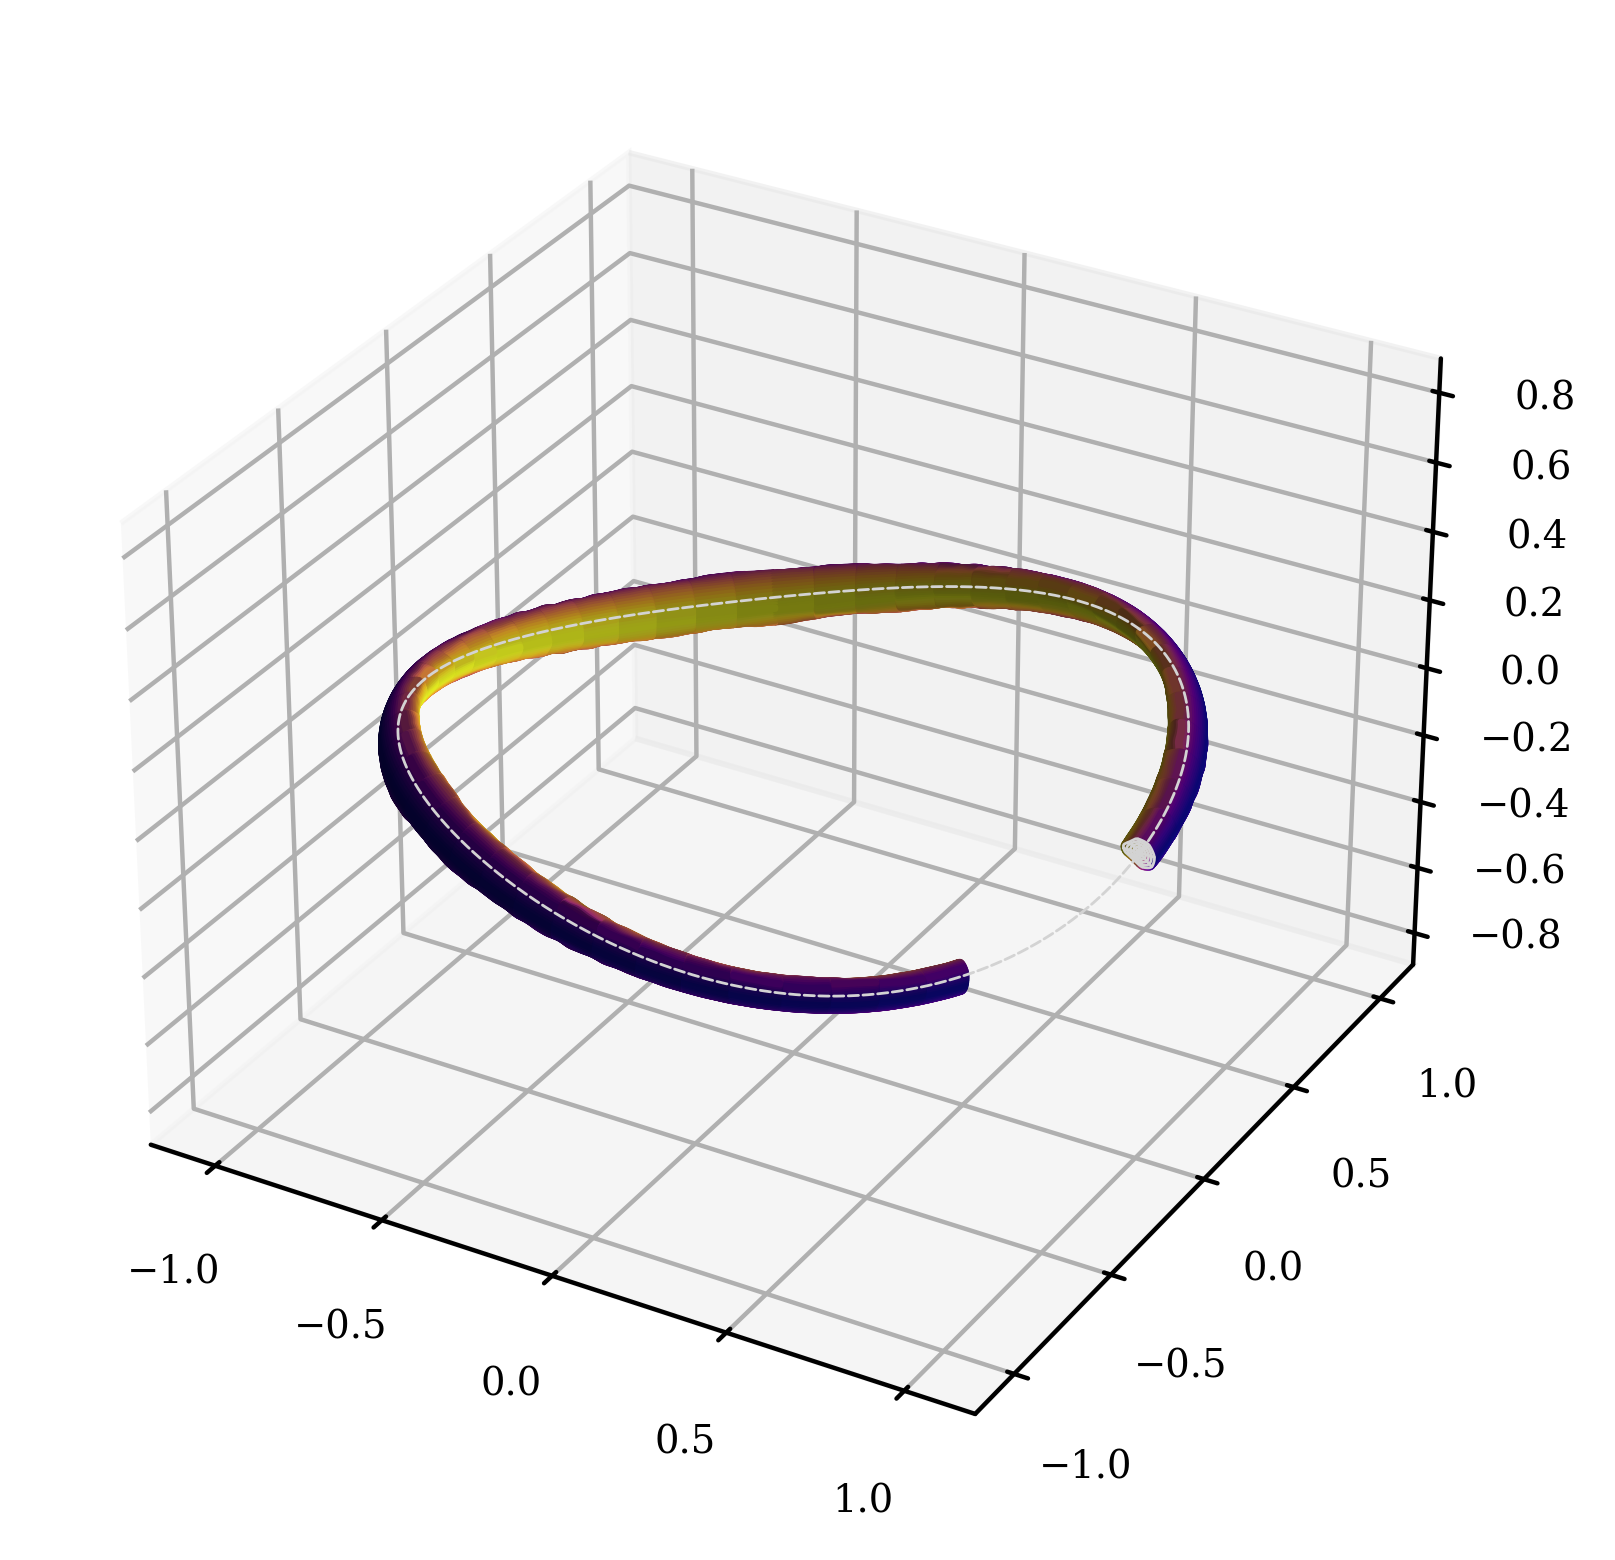

In [11]:
eq_fin.display()

In [12]:
eq_desc_list = []
eq_raw_list = []
aux_desc_list = []
for i in range(1, 7):
    eq_raw, eq_desc, aux_desc = aqsc_to_desc_near_axis(
        eq_fin, fin_eps_conv**2, n_max=i, 
        M=6, N=8, solve_force_balance=True,
        verbose=3
    )
    eq_raw_list.append(eq_raw)
    eq_desc_list.append(eq_desc)
    aux_desc_list.append(aux_desc)

Assuming stellarator symmetry.


/home/lf2869/Documents/Codes/DESC/desc/utils.py:563: UserWarning: iota profile is not an even power series.
  warnings.warn(msg, err)


Building objective: force-anisotropic
Precomputing transforms
Timer: Precomputing transforms = 282 ms
Timer: Objective build = 512 ms
Building objective: fixed Psi
Building objective: fixed pressure
Building objective: fixed iota
Building objective: fixed anisotropy
Building objective: fixed sheet current
Building objective: Fix Near Axis R Behavior
Building objective: Fix Near Axis Z Behavior
Building objective: Fix Near Axis Lambda Behavior
Building objective: self_consistency R
Building objective: self_consistency Z
Building objective: lambda gauge
Building objective: axis R self consistency
Building objective: axis Z self consistency
Timer: Objective build = 290 ms
Timer: LinearConstraintProjection build = 1.59 sec
Number of parameters: 636
Number of objectives: 4851
Timer: Initializing the optimization = 2.42 sec

Starting optimization
Using method: lsq-exact
Solver options:
------------------------------------------------------------
Maximum Function Evaluations       : 501
Maxim

/home/lf2869/Documents/Codes/DESC/desc/utils.py:563: UserWarning: iota profile is not an even power series.
  warnings.warn(msg, err)


Building objective: force-anisotropic
Precomputing transforms
Timer: Precomputing transforms = 46.8 ms
Timer: Objective build = 55.9 ms
Building objective: fixed Psi
Building objective: fixed pressure
Building objective: fixed iota
Building objective: fixed anisotropy
Building objective: fixed sheet current
Building objective: Fix Near Axis R Behavior
Building objective: Fix Near Axis Z Behavior
Building objective: Fix Near Axis Lambda Behavior
Building objective: self_consistency R
Building objective: self_consistency Z
Building objective: lambda gauge
Building objective: axis R self consistency
Building objective: axis Z self consistency
Timer: Objective build = 125 ms
Timer: LinearConstraintProjection build = 284 ms
Number of parameters: 636
Number of objectives: 4851
Timer: Initializing the optimization = 480 ms

Starting optimization
Using method: lsq-exact
Solver options:
------------------------------------------------------------
Maximum Function Evaluations       : 501
Maximum

...

Building objective: force-anisotropic
Precomputing transforms
Timer: Precomputing transforms = 47.4 ms
Timer: Objective build = 56.8 ms
Building objective: fixed Psi
Building objective: fixed pressure
Building objective: fixed iota
Building objective: fixed anisotropy
Building objective: fixed sheet current
Building objective: Fix Near Axis R Behavior
Building objective: Fix Near Axis Z Behavior
Building objective: Fix Near Axis Lambda Behavior
Building objective: self_consistency R
Building objective: self_consistency Z
Building objective: lambda gauge
Building objective: axis R self consistency
Building objective: axis Z self consistency
Timer: Objective build = 126 ms
Timer: LinearConstraintProjection build = 292 ms
Number of parameters: 636
Number of objectives: 4851
Timer: Initializing the optimization = 488 ms

Starting optimization
Using method: lsq-exact
Solver options:
------------------------------------------------------------
Maximum Function Evaluations       : 501
Maximum

/home/lf2869/Documents/Codes/DESC/desc/utils.py:563: UserWarning: iota profile is not an even power series.
  warnings.warn(msg, err)


Building objective: force-anisotropic
Precomputing transforms
Timer: Precomputing transforms = 47.7 ms
Timer: Objective build = 57.1 ms
Building objective: fixed Psi
Building objective: fixed pressure
Building objective: fixed iota
Building objective: fixed anisotropy
Building objective: fixed sheet current
Building objective: Fix Near Axis R Behavior
Building objective: Fix Near Axis Z Behavior
Building objective: Fix Near Axis Lambda Behavior
Building objective: self_consistency R
Building objective: self_consistency Z
Building objective: lambda gauge
Building objective: axis R self consistency
Building objective: axis Z self consistency
Timer: Objective build = 125 ms
Timer: LinearConstraintProjection build = 265 ms
Number of parameters: 636
Number of objectives: 4851
Timer: Initializing the optimization = 461 ms

Starting optimization
Using method: lsq-exact
Solver options:
------------------------------------------------------------
Maximum Function Evaluations       : 501
Maximum

/home/lf2869/Documents/Codes/DESC/desc/utils.py:563: UserWarning: iota profile is not an even power series.
  warnings.warn(msg, err)


Building objective: force-anisotropic
Precomputing transforms
Timer: Precomputing transforms = 47.6 ms
Timer: Objective build = 56.7 ms
Building objective: fixed Psi
Building objective: fixed pressure
Building objective: fixed iota
Building objective: fixed anisotropy
Building objective: fixed sheet current
Building objective: Fix Near Axis R Behavior
Building objective: Fix Near Axis Z Behavior
Building objective: Fix Near Axis Lambda Behavior
Building objective: self_consistency R
Building objective: self_consistency Z
Building objective: lambda gauge
Building objective: axis R self consistency
Building objective: axis Z self consistency
Timer: Objective build = 125 ms
Timer: LinearConstraintProjection build = 157 ms
Number of parameters: 636
Number of objectives: 4851
Timer: Initializing the optimization = 352 ms

Starting optimization
Using method: lsq-exact
Solver options:
------------------------------------------------------------
Maximum Function Evaluations       : 501
Maximum

In [13]:
eq_desc_list2 = []
eq_raw_list2 = []
aux_desc_list2 = []
for i in range(1, 7):
    eq_raw, eq_desc, aux_desc = aqsc_to_desc_near_axis(
        eq_fin, fin_eps_conv**2/2, n_max=i, 
        M=6, N=8, solve_force_balance=True,
        verbose=3
    )
    eq_raw_list2.append(eq_raw)
    eq_desc_list2.append(eq_desc)
    aux_desc_list2.append(aux_desc)

Assuming stellarator symmetry.


/home/lf2869/Documents/Codes/DESC/desc/utils.py:563: UserWarning: iota profile is not an even power series.
  warnings.warn(msg, err)


Building objective: force-anisotropic
Precomputing transforms
Timer: Precomputing transforms = 47.3 ms
Timer: Objective build = 56.3 ms
Building objective: fixed Psi
Building objective: fixed pressure
Building objective: fixed iota
Building objective: fixed anisotropy
Building objective: fixed sheet current
Building objective: Fix Near Axis R Behavior
Building objective: Fix Near Axis Z Behavior
Building objective: Fix Near Axis Lambda Behavior
Building objective: self_consistency R
Building objective: self_consistency Z
Building objective: lambda gauge
Building objective: axis R self consistency
Building objective: axis Z self consistency
Timer: Objective build = 124 ms
Timer: LinearConstraintProjection build = 156 ms
Number of parameters: 636
Number of objectives: 4851
Timer: Initializing the optimization = 350 ms

Starting optimization
Using method: lsq-exact
Solver options:
------------------------------------------------------------
Maximum Function Evaluations       : 501
Maximum

/home/lf2869/Documents/Codes/DESC/desc/utils.py:563: UserWarning: iota profile is not an even power series.
  warnings.warn(msg, err)


Building objective: force-anisotropic
Precomputing transforms
Timer: Precomputing transforms = 47.9 ms
Timer: Objective build = 57.7 ms
Building objective: fixed Psi
Building objective: fixed pressure
Building objective: fixed iota
Building objective: fixed anisotropy
Building objective: fixed sheet current
Building objective: Fix Near Axis R Behavior
Building objective: Fix Near Axis Z Behavior
Building objective: Fix Near Axis Lambda Behavior
Building objective: self_consistency R
Building objective: self_consistency Z
Building objective: lambda gauge
Building objective: axis R self consistency
Building objective: axis Z self consistency
Timer: Objective build = 128 ms
Timer: LinearConstraintProjection build = 181 ms
Number of parameters: 636
Number of objectives: 4851
Timer: Initializing the optimization = 382 ms

Starting optimization
Using method: lsq-exact
Solver options:
------------------------------------------------------------
Maximum Function Evaluations       : 501
Maximum

...

Building objective: force-anisotropic
Precomputing transforms
Timer: Precomputing transforms = 47.6 ms
Timer: Objective build = 57.2 ms
Building objective: fixed Psi
Building objective: fixed pressure
Building objective: fixed iota
Building objective: fixed anisotropy
Building objective: fixed sheet current
Building objective: Fix Near Axis R Behavior
Building objective: Fix Near Axis Z Behavior
Building objective: Fix Near Axis Lambda Behavior
Building objective: self_consistency R
Building objective: self_consistency Z
Building objective: lambda gauge
Building objective: axis R self consistency
Building objective: axis Z self consistency
Timer: Objective build = 127 ms
Timer: LinearConstraintProjection build = 155 ms
Number of parameters: 636
Number of objectives: 4851
Timer: Initializing the optimization = 353 ms

Starting optimization
Using method: lsq-exact
Solver options:
------------------------------------------------------------
Maximum Function Evaluations       : 501
Maximum

/home/lf2869/Documents/Codes/DESC/desc/utils.py:563: UserWarning: iota profile is not an even power series.
  warnings.warn(msg, err)


Building objective: force-anisotropic
Precomputing transforms
Timer: Precomputing transforms = 47.3 ms
Timer: Objective build = 56.1 ms
Building objective: fixed Psi
Building objective: fixed pressure
Building objective: fixed iota
Building objective: fixed anisotropy
Building objective: fixed sheet current
Building objective: Fix Near Axis R Behavior
Building objective: Fix Near Axis Z Behavior
Building objective: Fix Near Axis Lambda Behavior
Building objective: self_consistency R
Building objective: self_consistency Z
Building objective: lambda gauge
Building objective: axis R self consistency
Building objective: axis Z self consistency
Timer: Objective build = 124 ms
Timer: LinearConstraintProjection build = 144 ms
Number of parameters: 636
Number of objectives: 4851
Timer: Initializing the optimization = 338 ms

Starting optimization
Using method: lsq-exact
Solver options:
------------------------------------------------------------
Maximum Function Evaluations       : 501
Maximum

/home/lf2869/Documents/Codes/DESC/desc/utils.py:563: UserWarning: iota profile is not an even power series.
  warnings.warn(msg, err)


Building objective: force-anisotropic
Precomputing transforms
Timer: Precomputing transforms = 47.2 ms
Timer: Objective build = 56.3 ms
Building objective: fixed Psi
Building objective: fixed pressure
Building objective: fixed iota
Building objective: fixed anisotropy
Building objective: fixed sheet current
Building objective: Fix Near Axis R Behavior
Building objective: Fix Near Axis Z Behavior
Building objective: Fix Near Axis Lambda Behavior
Building objective: self_consistency R
Building objective: self_consistency Z
Building objective: lambda gauge
Building objective: axis R self consistency
Building objective: axis Z self consistency
Timer: Objective build = 124 ms
Timer: LinearConstraintProjection build = 182 ms
Number of parameters: 636
Number of objectives: 4851
Timer: Initializing the optimization = 375 ms

Starting optimization
Using method: lsq-exact
Solver options:
------------------------------------------------------------
Maximum Function Evaluations       : 501
Maximum

In [14]:
prec_qa_eq = get('precise_QA')
prec_qh_eq = get('precise_QH')
wistell_a_eq = get('WISTELL-A')
estell_eq = get('ESTELL')
ncsx_eq = get('NCSX')

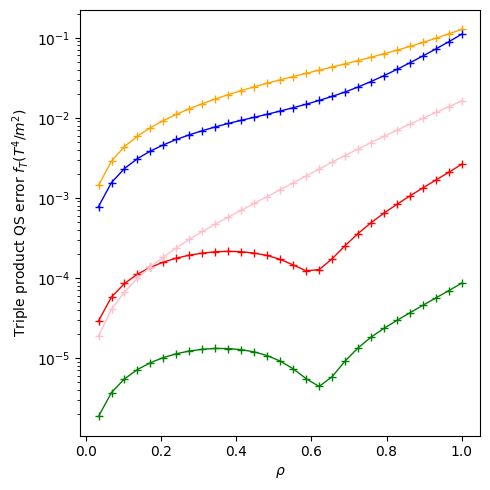

In [15]:
plt.style.use('default')
rho_arr = np.linspace(0., 1, 30)
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
# fig, ax = plot_qs_error(
#     eq, 
#     ax=ax,
#     fC=False, fB=False, 
#     labels=['pyAQSC sln', 'pyAQSC sln', 'pyAQSC sln'], 
#     color=['b', 'b', 'grey'],
#     legend=False,
#     figsize=(8,8)
# )
# fig, ax = plot_qs_error(
#     eq_full, 
#     marker='+',
#     ax=ax,
#     fC=False, fB=False, 
#     labels=['DESC fit', 'DESC fit', 'DESC fit'], 
#     color=['b', 'b', 'black'],
#     legend=False,
#     rho=rho_arr,
#     figsize=(8,8)
# )
fig, ax = plot_qs_error(
    prec_qa_eq, 
    marker='+',
    fC=False, fB=False, 
    labels=['Precise QA', 'Precise QA', 'Precise QA'], 
    ax=ax,
    color=['b', 'b', 'green'],
    rho=rho_arr,
    legend=False
)
fig, ax = plot_qs_error(
    prec_qh_eq, 
    marker='+',
    fC=False, fB=False, 
    labels=['Precise QH', 'Precise QH', 'Precise QH'], 
    ax=ax,
    color=['b', 'b', 'red'],
    rho=rho_arr,
    legend=False
)
fig, ax = plot_qs_error(
    wistell_a_eq, 
    marker='+',
    fC=False, fB=False, 
    labels=['WISTELL-A', 'WISTELL-A', 'WISTELL-A'], 
    ax=ax,
    color=['b', 'b', 'orange'],
    rho=rho_arr,
    legend=False
)
fig, ax = plot_qs_error(
    estell_eq, 
    marker='+',
    fC=False, fB=False, 
    labels=['ESTELL', 'ESTELL', 'ESTELL'], 
    ax=ax,
    color=['b', 'b', 'pink'],
    rho=rho_arr,
    legend=False
)
fig, ax = plot_qs_error(
    ncsx_eq, 
    marker='+',
    fC=False, fB=False, 
    labels=['NCSX', 'NCSX', 'NCSX'], 
    ax=ax,
    ylabel='Triple product QS error $f_T(T^4/m^2)$',
    color=['b', 'b', 'blue'],
    rho=rho_arr,
    legend=False
)



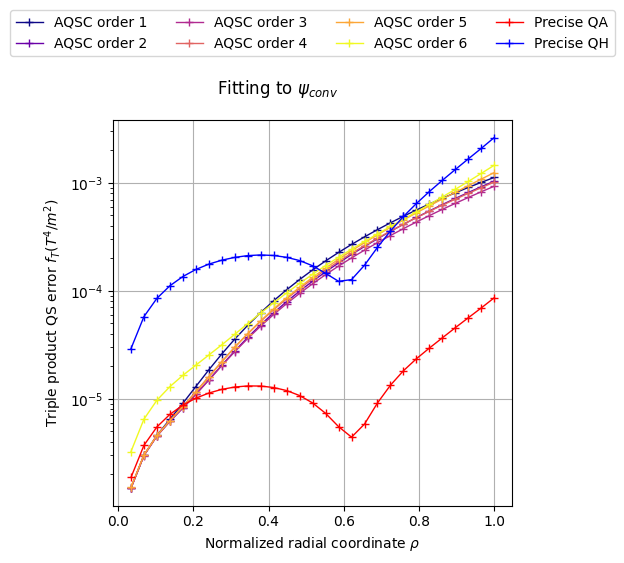

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
n_lines = len(eq_desc_list)
cmap = mpl.colormaps['plasma']
colors = cmap(np.linspace(0, 1, n_lines))
for i, color in enumerate(colors): 
    fig, ax = plot_qs_error(
        eq_desc_list[i], 
        marker='+',
        fC=False, fB=False, 
        labels=['', '', 'AQSC order ' + str(i+1) ], 
        ax=ax,
        ylabel='Triple product QS error $f_T(T^4/m^2)$',
        color=['b', 'b', color],
        rho=rho_arr,
        legend=False
    )

fig, ax = plot_qs_error(
    prec_qa_eq, 
    marker='+',
    fC=False, fB=False, 
    labels=['', '', 'Precise QA'], 
    ax=ax,
    ylabel='Triple product QS error $f_T(T^4/m^2)$',
    color=['b', 'b', 'red'],
    rho=rho_arr,
    legend=False
)
fig, ax = plot_qs_error(
    prec_qh_eq, 
    marker='+',
    fC=False, fB=False, 
    labels=['', '', 'Precise QH'], 
    ax=ax,
    ylabel='Triple product QS error $f_T(T^4/m^2)$',
    color=['b', 'b', 'blue'],
    rho=rho_arr,
    legend=False
)
lgd = fig.legend(loc='upper center', bbox_to_anchor=(0.57,1.13), ncol=4)
ax.set_xlabel(r'Normalized radial coordinate $\rho$')
ax.grid()
fig.suptitle(r'Fitting to $\psi_{conv}$')
fig.savefig('./qs_error_order.pdf', format='pdf', bbox_extra_artists=(lgd,), bbox_inches='tight')

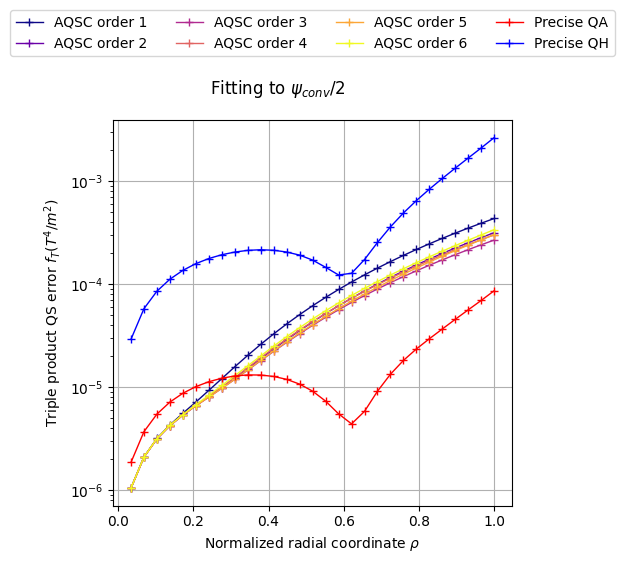

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
n_lines = len(eq_desc_list2)
cmap = mpl.colormaps['plasma']
colors = cmap(np.linspace(0, 1, n_lines))
for i, color in enumerate(colors): 
    fig, ax = plot_qs_error(
        eq_desc_list2[i], 
        marker='+',
        fC=False, fB=False, 
        labels=['', '', 'AQSC order ' + str(i+1) ], 
        ax=ax,
        ylabel='Triple product QS error $f_T(T^4/m^2)$',
        color=['b', 'b', color],
        rho=rho_arr,
        legend=False
    )
fig, ax = plot_qs_error(
    prec_qa_eq, 
    marker='+',
    fC=False, fB=False, 
    labels=['', '', 'Precise QA'], 
    ax=ax,
    ylabel='Triple product QS error $f_T(T^4/m^2)$',
    color=['b', 'b', 'red'],
    rho=rho_arr,
    legend=False
)
fig, ax = plot_qs_error(
    prec_qh_eq, 
    marker='+',
    fC=False, fB=False, 
    labels=['', '', 'Precise QH'], 
    ax=ax,
    ylabel='Triple product QS error $f_T(T^4/m^2)$',
    color=['b', 'b', 'blue'],
    rho=rho_arr,
    legend=False
)
lgd = fig.legend(loc='upper center', bbox_to_anchor=(0.57,1.13), ncol=4)
ax.set_xlabel(r'Normalized radial coordinate $\rho$')
ax.grid()
fig.suptitle(r'Fitting to $\psi_{conv}/2$')
fig.savefig('./qs_error_order2.pdf', format='pdf', bbox_extra_artists=(lgd,), bbox_inches='tight')

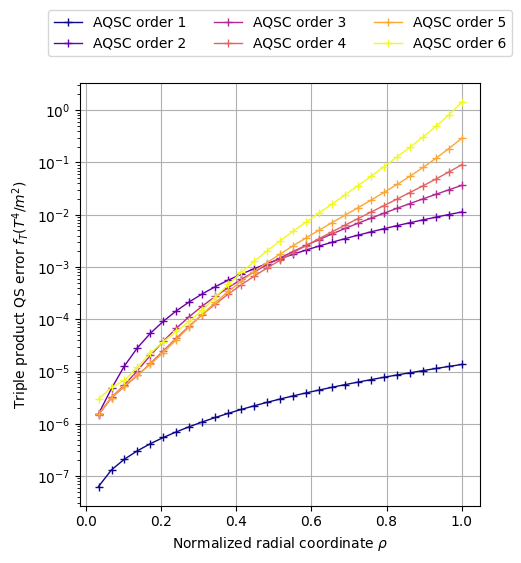

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
n_lines = len(eq_desc_list)
cmap = mpl.colormaps['plasma']
colors = cmap(np.linspace(0, 1, n_lines))
for i, color in enumerate(colors): 
    fig, ax = plot_qs_error(
        eq_raw_list[i], 
        marker='+',
        fC=False, fB=False, 
        labels=['', '', 'AQSC order ' + str(i+1) ], 
        ax=ax,
        ylabel='Triple product QS error $f_T(T^4/m^2)$',
        color=['b', 'b', color],
        rho=rho_arr,
        legend=False
    )
lgd = fig.legend(loc='upper center', bbox_to_anchor=(0.57,1.13), ncol=3)
ax.set_xlabel(r'Normalized radial coordinate $\rho$')
ax.grid()
fig.savefig('./qs_error_order_raw.pdf', format='pdf', bbox_extra_artists=(lgd,), bbox_inches='tight')

(<Figure size 1200x1000 with 6 Axes>,
 array([<Axes: title={'center': '$\\phi \\cdot N_{FP}/2\\pi = 0.000$'}, xlabel='$R ~(\\mathrm{m})$', ylabel='$Z ~(\\mathrm{m})$'>,
        <Axes: title={'center': '$\\phi \\cdot N_{FP}/2\\pi = 0.167$'}, xlabel='$R ~(\\mathrm{m})$', ylabel='$Z ~(\\mathrm{m})$'>,
        <Axes: title={'center': '$\\phi \\cdot N_{FP}/2\\pi = 0.333$'}, xlabel='$R ~(\\mathrm{m})$', ylabel='$Z ~(\\mathrm{m})$'>,
        <Axes: title={'center': '$\\phi \\cdot N_{FP}/2\\pi = 0.500$'}, xlabel='$R ~(\\mathrm{m})$', ylabel='$Z ~(\\mathrm{m})$'>,
        <Axes: title={'center': '$\\phi \\cdot N_{FP}/2\\pi = 0.667$'}, xlabel='$R ~(\\mathrm{m})$', ylabel='$Z ~(\\mathrm{m})$'>,
        <Axes: title={'center': '$\\phi \\cdot N_{FP}/2\\pi = 0.833$'}, xlabel='$R ~(\\mathrm{m})$', ylabel='$Z ~(\\mathrm{m})$'>],
       dtype=object))

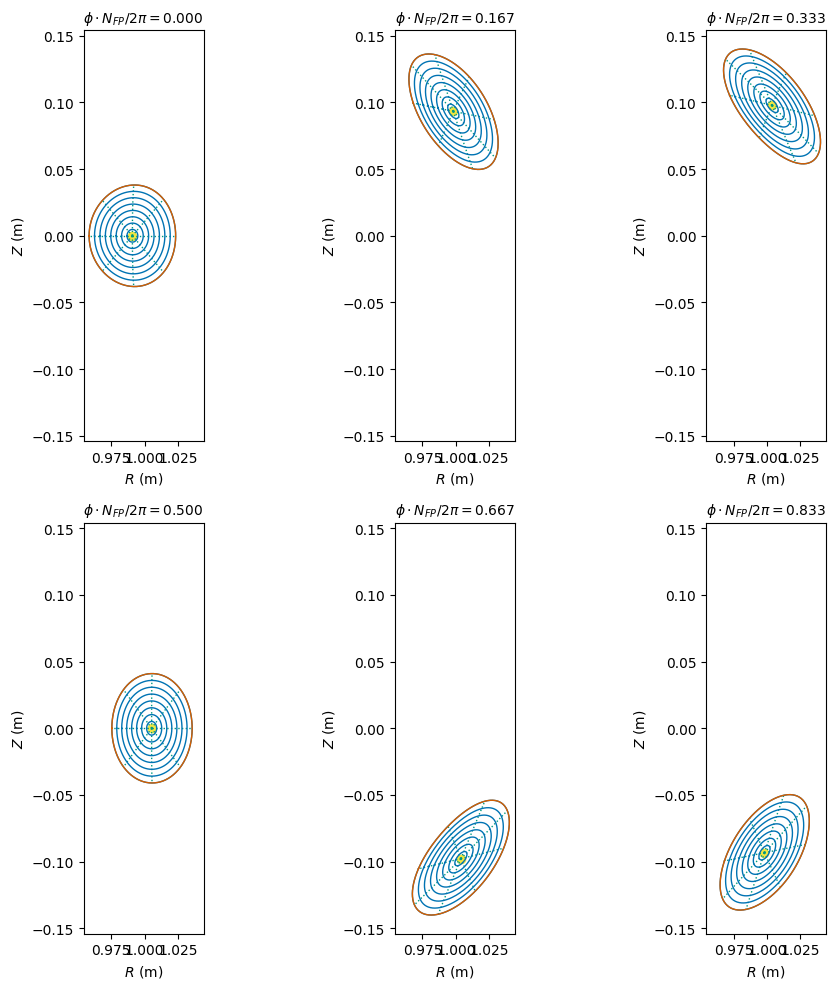

In [19]:
plot_surfaces(eq_desc_list2[0], rho=8, theta=8)

In [20]:
# Plot divergence
def divergence_plot(eq):
    amp_B_psi_coef_cp = eq.unknown['B_psi_coef_cp'].get_max_order_by_order()
    amp_B_theta_coef_cp = eq.unknown['B_theta_coef_cp'].get_max_order_by_order()
    amp_Delta_coef_cp = eq.unknown['Delta_coef_cp'].get_max_order_by_order()
    amp_X_coef_cp = eq.unknown['X_coef_cp'].get_max_order_by_order()
    amp_Y_coef_cp = eq.unknown['Y_coef_cp'].get_max_order_by_order()
    amp_Z_coef_cp = eq.unknown['Z_coef_cp'].get_max_order_by_order()
    amp_p_perp_coef_cp = eq.unknown['p_perp_coef_cp'].get_max_order_by_order()
    J_list_peak = []
    Cb_list_peak = []
    Ck_list_peak = []
    Ct_list_peak = []
    I_list_peak = []
    II_list_peak = []
    III_list_peak = []
    for i in jnp.arange(eq.get_order())+1:
        (
            J,
            Cb,
            Ck,
            Ct,
            I,
            II,
            III,
        ) = eq.check_governing_equations(i, normalize=False)
        (J, Cb, Ck, Ct, I, II, III) = eq.check_governing_equations(i, normalize=True)
        J_list_peak.append(J.get_max(500, 500))
        Cb_list_peak.append(Cb.get_max(500, 500))
        Ck_list_peak.append(Ck.get_max(500, 500))
        Ct_list_peak.append(Ct.get_max(500, 500))
        I_list_peak.append(I.get_max(500, 500))
        II_list_peak.append(II.get_max(500, 500))
        III_list_peak.append(III.get_max(500, 500))


    J_list_peak = jnp.array(J_list_peak)
    J_list_peak = jnp.where(J_list_peak==0, jnp.nan, J_list_peak)
    Cb_list_peak = jnp.array(Cb_list_peak)
    Cb_list_peak = jnp.where(Cb_list_peak==0, jnp.nan, Cb_list_peak)
    Ck_list_peak = jnp.array(Ck_list_peak)
    Ck_list_peak = jnp.where(Ck_list_peak==0, jnp.nan, Ck_list_peak)
    Ct_list_peak = jnp.array(Ct_list_peak)
    Ct_list_peak = jnp.where(Ct_list_peak==0, jnp.nan, Ct_list_peak)
    I_list_peak = jnp.array(I_list_peak)
    I_list_peak = jnp.where(I_list_peak==0, jnp.nan, I_list_peak)
    II_list_peak = jnp.array(II_list_peak)
    II_list_peak = jnp.where(II_list_peak==0, jnp.nan, II_list_peak)
    III_list_peak = jnp.array(III_list_peak)
    III_list_peak = jnp.where(III_list_peak==0, jnp.nan, III_list_peak)

    plt.plot(amp_B_psi_coef_cp)
    plt.plot(amp_B_theta_coef_cp)
    plt.plot(amp_Delta_coef_cp)
    plt.plot(amp_X_coef_cp)
    plt.plot(amp_Y_coef_cp)
    plt.plot(amp_Z_coef_cp)
    plt.plot(amp_p_perp_coef_cp)
    plt.plot(J_list_peak, label=r'$J^n$ error', marker='', linestyle='--', alpha = 0.5)
    plt.plot(Cb_list_peak, label=r'$C_{b}^{n-1}$ error', marker='', linestyle='--', alpha = 0.5)
    plt.plot(Ck_list_peak, label=r'$C_{\kappa}^{n-1}$ error', marker='', linestyle='--', alpha = 0.5)
    plt.plot(Ct_list_peak, label=r'$C_{\tau}^{n-1}$ error', marker='', linestyle='--', alpha = 0.5)
    plt.plot(I_list_peak, label=r'$I^n$ error', marker='', linestyle='--', alpha = 0.5)
    plt.plot(II_list_peak, label=r'$II^n$ error', marker='', linestyle='--', alpha = 0.5)
    plt.plot(III_list_peak, label=r'$III^{n-2}$ error', marker='', linestyle='--', alpha = 0.5)
    plt.yscale('log')

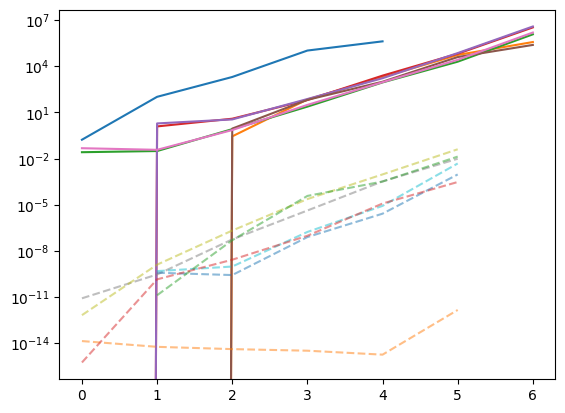

In [21]:
divergence_plot(eq_fin)

(<Figure size 1200x1000 with 6 Axes>,
 array([<Axes: title={'center': '$\\phi \\cdot N_{FP}/2\\pi = 0.000$'}, xlabel='$R ~(\\mathrm{m})$', ylabel='$Z ~(\\mathrm{m})$'>,
        <Axes: title={'center': '$\\phi \\cdot N_{FP}/2\\pi = 0.167$'}, xlabel='$R ~(\\mathrm{m})$', ylabel='$Z ~(\\mathrm{m})$'>,
        <Axes: title={'center': '$\\phi \\cdot N_{FP}/2\\pi = 0.333$'}, xlabel='$R ~(\\mathrm{m})$', ylabel='$Z ~(\\mathrm{m})$'>,
        <Axes: title={'center': '$\\phi \\cdot N_{FP}/2\\pi = 0.500$'}, xlabel='$R ~(\\mathrm{m})$', ylabel='$Z ~(\\mathrm{m})$'>,
        <Axes: title={'center': '$\\phi \\cdot N_{FP}/2\\pi = 0.667$'}, xlabel='$R ~(\\mathrm{m})$', ylabel='$Z ~(\\mathrm{m})$'>,
        <Axes: title={'center': '$\\phi \\cdot N_{FP}/2\\pi = 0.833$'}, xlabel='$R ~(\\mathrm{m})$', ylabel='$Z ~(\\mathrm{m})$'>],
       dtype=object))

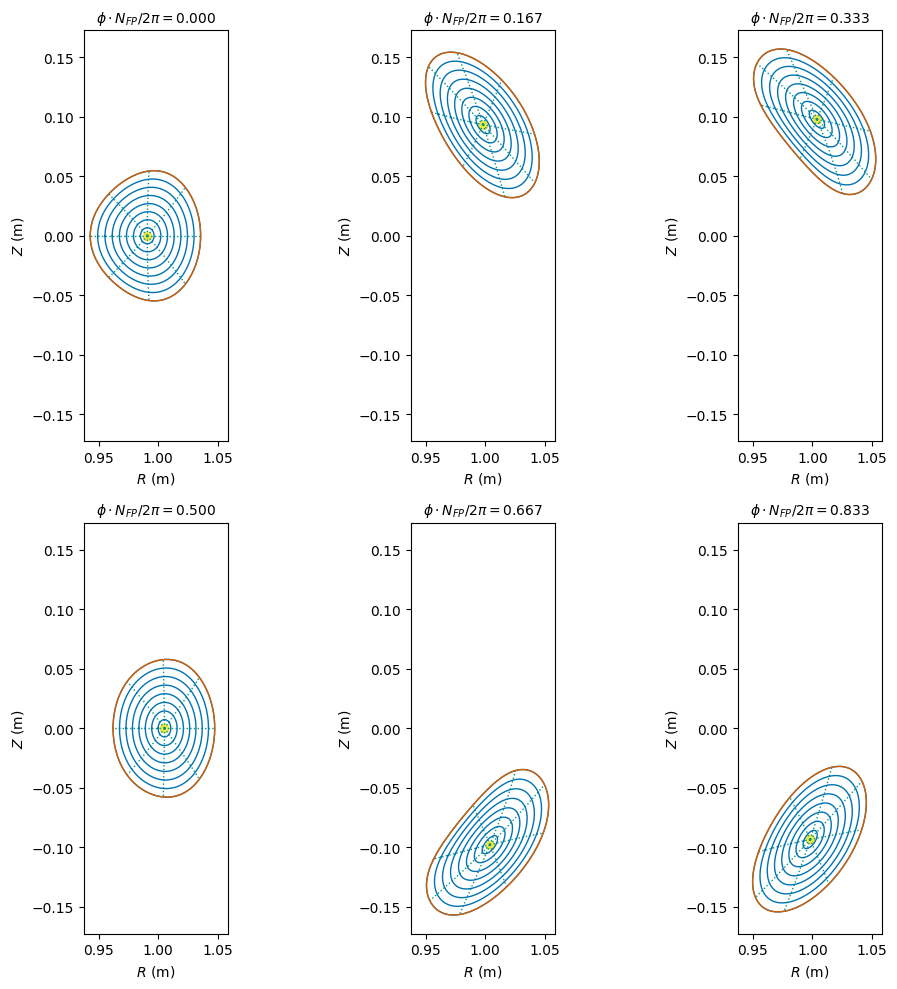

In [22]:
plot_surfaces(eq_desc_list[-1], rho=8, theta=8)

(<Figure size 400x400 with 1 Axes>,
 <Axes: xlabel='$\\rho$', ylabel='$ \\iota ~(~)$'>)

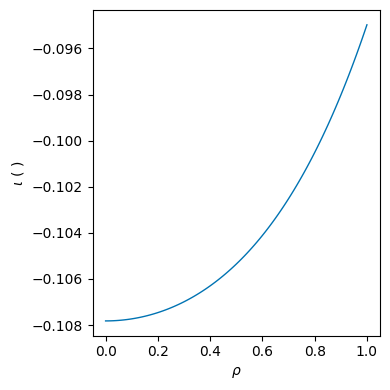

In [23]:
plot_1d(eq_desc_list[-1], 'iota')

(<Figure size 400x400 with 1 Axes>,
 <Axes: xlabel='$\\rho$', ylabel='$ p ~(Pa)$'>)

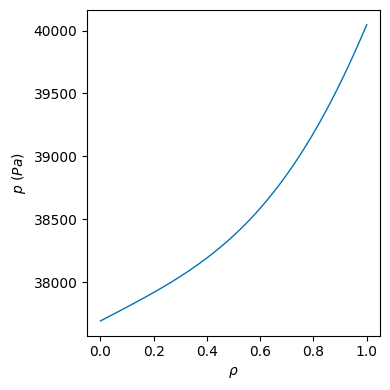

In [24]:
plot_1d(eq_desc_list[-1], 'pressure')

(<Figure size 1200x1000 with 6 Axes>,
 array([<Axes: title={'center': '$\\phi \\cdot N_{FP}/2\\pi = 0.000$'}, xlabel='$R ~(\\mathrm{m})$', ylabel='$Z ~(\\mathrm{m})$'>,
        <Axes: title={'center': '$\\phi \\cdot N_{FP}/2\\pi = 0.167$'}, xlabel='$R ~(\\mathrm{m})$', ylabel='$Z ~(\\mathrm{m})$'>,
        <Axes: title={'center': '$\\phi \\cdot N_{FP}/2\\pi = 0.333$'}, xlabel='$R ~(\\mathrm{m})$', ylabel='$Z ~(\\mathrm{m})$'>,
        <Axes: title={'center': '$\\phi \\cdot N_{FP}/2\\pi = 0.500$'}, xlabel='$R ~(\\mathrm{m})$', ylabel='$Z ~(\\mathrm{m})$'>,
        <Axes: title={'center': '$\\phi \\cdot N_{FP}/2\\pi = 0.667$'}, xlabel='$R ~(\\mathrm{m})$', ylabel='$Z ~(\\mathrm{m})$'>,
        <Axes: title={'center': '$\\phi \\cdot N_{FP}/2\\pi = 0.833$'}, xlabel='$R ~(\\mathrm{m})$', ylabel='$Z ~(\\mathrm{m})$'>],
       dtype=object))

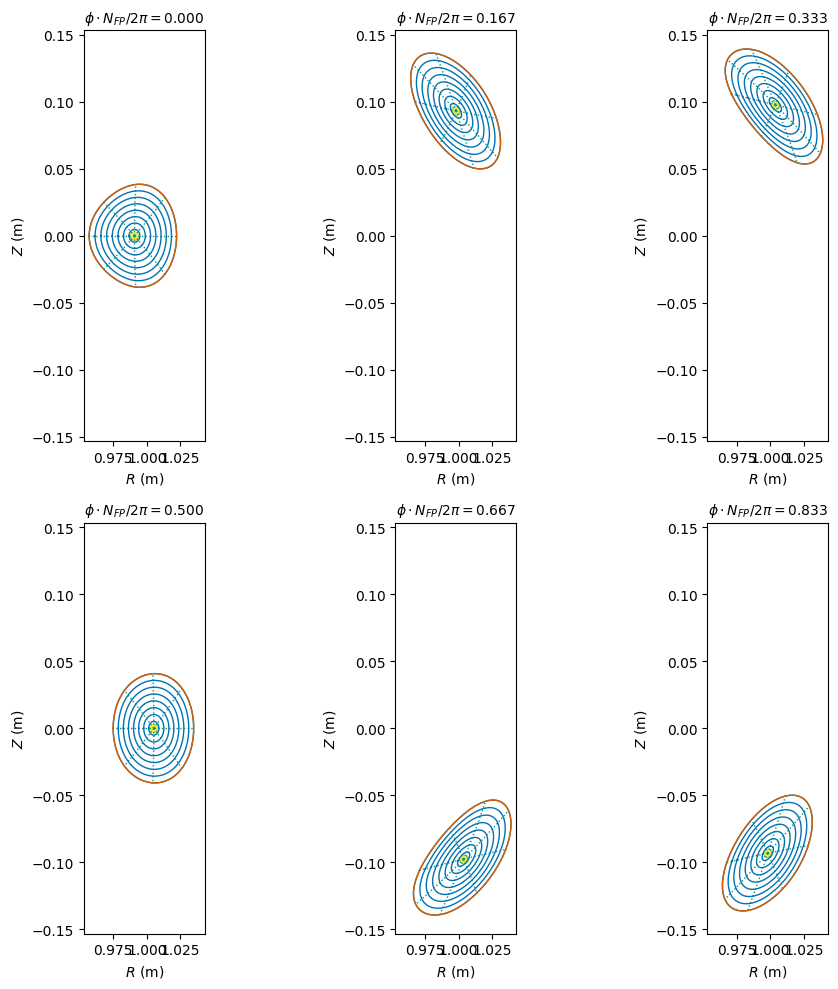

In [25]:
plot_surfaces(eq_desc_list2[-1], rho=8, theta=8)